# **<u>Exploratory Data Analysis</u>**

In [1]:
import pandas as pd
from educast.constants import INTERIM_DATA_DIR

In [2]:
df = pd.read_csv(INTERIM_DATA_DIR / "flattened_grades_private.csv")
df.head()

/var/folders/zy/vwhqt1dn6bx96gfjzf8pt7qm0000gn/T/ipykernel_90875/1101935410.py:1: DtypeWarning: Columns (15,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INTERIM_DATA_DIR / "flattened_grades_private.csv")


,id,itemid,userid,rawgrade,rawgrademax,rawgrademin,rawscaleid,usermodified,finalgrade,hidden,...,aggregationcoef,sortorder,display,decimals,needsupdate,aggregationcoef2,weightoverride,_term,_course_id_dir,_source_file
0,526288,526288,165852,NaN,10.0,0.0,NaN,165852.0,NaN,0,...,1.0,5,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
1,426388,426388,165852,NaN,10.0,0.0,NaN,NaN,0.0,0,...,0.0,1,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
2,526255,526255,165852,NaN,10.0,0.0,NaN,NaN,NaN,0,...,1.0,2,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
3,526268,526268,165852,NaN,10.0,0.0,NaN,NaN,NaN,0,...,1.0,3,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
4,526287,526287,165852,NaN,10.0,0.0,NaN,NaN,NaN,0,...,1.0,4,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json


In [3]:
df.shape

(1533649, 51)

In [4]:
df.columns

Index(['id', 'itemid', 'userid', 'rawgrade', 'rawgrademax', 'rawgrademin',
       'rawscaleid', 'usermodified', 'finalgrade', 'hidden', 'locked',
       'locktime', 'exported', 'overridden', 'excluded', 'feedback',
       'feedbackformat', 'information', 'informationformat', 'timecreated',
       'timemodified', 'aggregationstatus', 'aggregationweight', 'courseid',
       'categoryid', 'itemname', 'itemtype', 'itemmodule', 'iteminstance',
       'itemnumber', 'iteminfo', 'idnumber', 'calculation', 'gradetype',
       'grademax', 'grademin', 'scaleid', 'outcomeid', 'gradepass',
       'multfactor', 'plusfactor', 'aggregationcoef', 'sortorder', 'display',
       'decimals', 'needsupdate', 'aggregationcoef2', 'weightoverride',
       '_term', '_course_id_dir', '_source_file'],
      dtype='object')

In [5]:
df['timecreated'].head()

0    2022-04-04 20:17:55
1    2022-01-31 11:22:05
2    2022-04-04 13:17:13
3    2022-04-04 13:47:45
4    2022-04-04 20:14:57
Name: timecreated, dtype: object

In [6]:
df['timecreated'] = pd.to_datetime(df['timecreated'], errors='coerce')

In [7]:
df['timecreated'].dt.month

0           4
1           1
2           4
3           4
4           4
           ..
1533644    12
1533645    12
1533646    12
1533647    12
1533648    12
Name: timecreated, Length: 1533649, dtype: int32

In [8]:
# Main dataframe now just takes the actual taken courses with final grade
df = df[
    (df['itemtype'] == 'course')
    & (df['finalgrade'].notna())
]

df

,id,itemid,userid,rawgrade,rawgrademax,rawgrademin,rawscaleid,usermodified,finalgrade,hidden,...,aggregationcoef,sortorder,display,decimals,needsupdate,aggregationcoef2,weightoverride,_term,_course_id_dir,_source_file
1,426388,426388,165852,NaN,10.0,0.0,NaN,NaN,0.00000,0,...,0.0,1,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
7,426388,426388,212799,NaN,10.0,0.0,NaN,NaN,0.00000,0,...,0.0,1,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
13,426388,426388,212268,NaN,10.0,0.0,NaN,NaN,0.00000,0,...,0.0,1,0,NaN,0,0.0,0,21-22-P,144743,21-22-P/144743/144743_kurso_ivertinimai.json
19,363596,363596,224350,NaN,10.0,0.0,NaN,NaN,7.25000,0,...,0.0,1,0,NaN,0,0.0,0,21-22-P,157502,21-22-P/157502/157502_kurso_ivertinimai.json
22,363596,363596,179098,NaN,10.0,0.0,NaN,NaN,6.75000,0,...,0.0,1,0,NaN,0,0.0,0,21-22-P,157502,21-22-P/157502/157502_kurso_ivertinimai.json
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1533626,319890,319890,147664,NaN,100.0,0.0,NaN,NaN,53.33333,0,...,0.0,1,0,NaN,0,0.0,0,21-22-R,141844,21-22-R/141844/141844_kurso_ivertinimai.json
1533629,319890,319890,126109,NaN,100.0,0.0,NaN,NaN,10.00000,0,...,0.0,1,0,NaN,0,0.0,0,21-22-R,141844,21-22-R/141844/141844_kurso_ivertinimai.json
1533632,319890,319890,144902,NaN,100.0,0.0,NaN,NaN,2.33333,0,...,0.0,1,0,NaN,0,0.0,0,21-22-R,141844,21-22-R/141844/141844_kurso_ivertinimai.json
1533635,319890,319890,169927,NaN,100.0,0.0,NaN,NaN,31.66667,0,...,0.0,1,0,NaN,0,0.0,0,21-22-R,141844,21-22-R/141844/141844_kurso_ivertinimai.json


In [9]:
df['month'] = df['timecreated'].dt.month
df['year'] = df['timecreated'].dt.year

In [10]:
df[['courseid', 'timecreated', 'month', 'year']].head()

,courseid,timecreated,month,year
1,144743,2022-01-31 11:22:05,1,2022
7,144743,2022-01-31 11:22:05,1,2022
13,144743,2022-01-31 11:22:05,1,2022
19,157502,2021-11-10 09:24:46,11,2021
22,157502,2021-11-10 09:24:46,11,2021


In [11]:
df.groupby('year')['courseid'].unique()

year
2009    [147135, 145631, 144381, 157643, 144284, 14651...
2010    [157953, 145493, 169006, 147301, 144655, 15840...
2011    [145652, 144523, 144457, 157618, 146730, 14516...
2012    [144807, 144543, 146704, 157606, 145569, 14353...
2013    [158463, 144609, 144935, 145678, 157812, 15805...
2014    [144788, 147396, 157617, 158083, 144392, 14717...
2015    [157595, 145727, 146103, 157858, 144335, 14509...
2016    [158128, 145570, 147414, 145177, 145719, 15763...
2017    [146821, 145004, 158143, 146930, 158065, 14696...
2018    [145468, 145696, 145466, 145492, 145699, 14514...
2019    [145201, 147391, 146023, 146227, 144789, 14505...
2020    [144327, 145808, 158586, 146479, 145056, 15759...
2021    [157502, 145033, 144916, 157965, 146817, 14458...
2022    [144743, 158581, 169235, 179401, 158544, 14432...
2023                                             [142592]
Name: courseid, dtype: object

In [12]:
unique_courses_per_year = df.groupby('year')['courseid'].nunique().reset_index()
unique_courses_per_year

,year,courseid
0,2009,37
1,2010,23
2,2011,37
3,2012,14
4,2013,32
5,2014,27
6,2015,31
7,2016,42
8,2017,88
9,2018,90


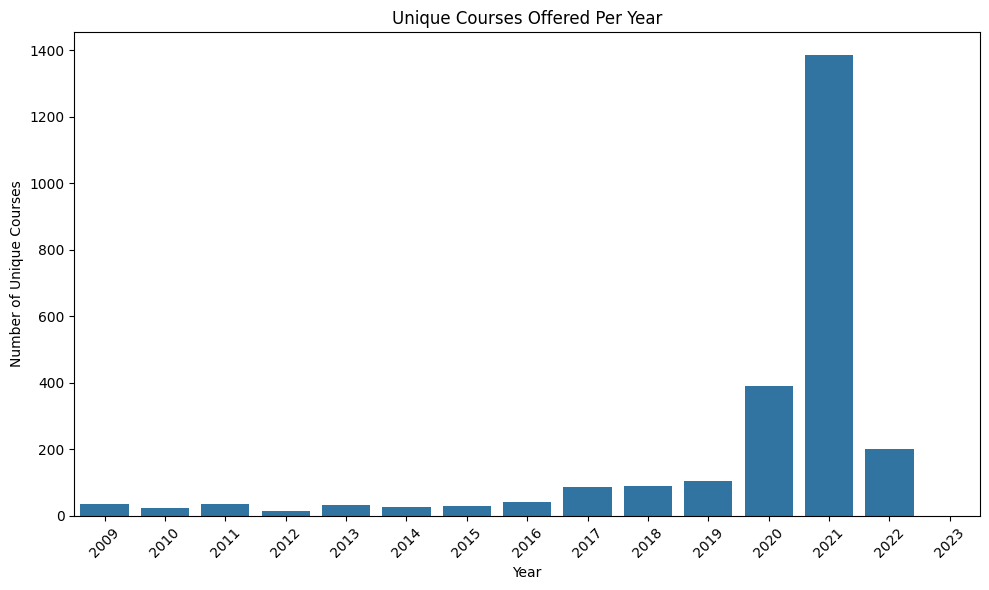

,year,unique_courses
0,2009,37
1,2010,23
2,2011,37
3,2012,14
4,2013,32
5,2014,27
6,2015,31
7,2016,42
8,2017,88
9,2018,90


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_courses_per_year = df.groupby('year')['courseid'].nunique().reset_index()
unique_courses_per_year.rename(columns={'courseid': 'unique_courses'}, inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(data=unique_courses_per_year, x='year', y='unique_courses')
plt.xlabel('Year')
plt.ylabel('Number of Unique Courses')
plt.title('Unique Courses Offered Per Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

unique_courses_per_year

In [14]:
unique_per_year = df.groupby('year')['userid'].nunique().reset_index()
unique_per_year.rename(columns={'userid': 'unique_students'}, inplace=True)
unique_per_year

,year,unique_students
0,2009,1069
1,2010,1100
2,2011,863
3,2012,233
4,2013,454
5,2014,581
6,2015,1156
7,2016,1387
8,2017,1548
9,2018,1443


/var/folders/zy/vwhqt1dn6bx96gfjzf8pt7qm0000gn/T/ipykernel_90875/503024795.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


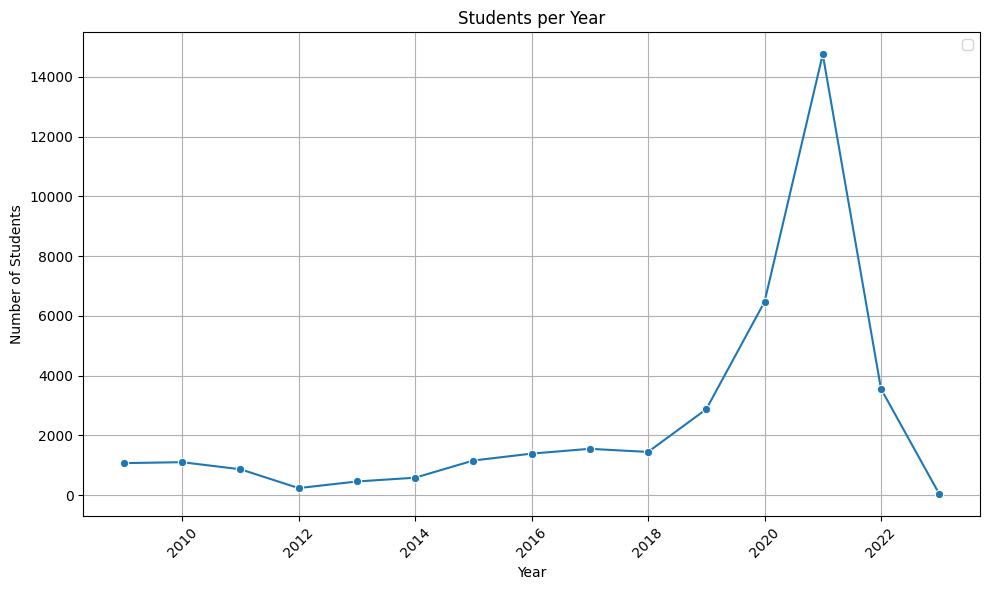

In [15]:
plt.figure(figsize=(10,6))
sns.lineplot(data=unique_per_year, x='year', y='unique_students', marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Students')
plt.title('Students per Year')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

## **Entries/enrollments/students data per year**

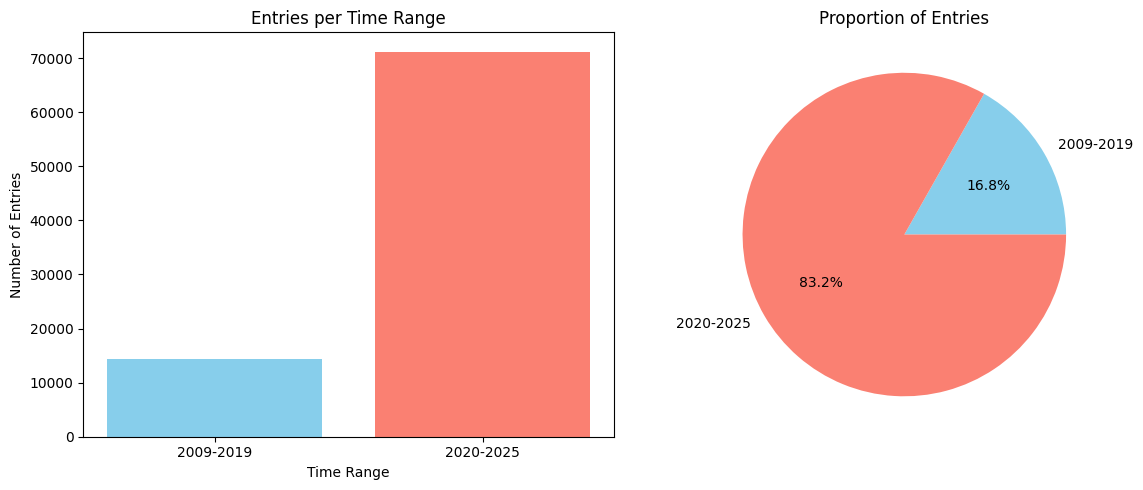

In [16]:
df_timecreated_non_nan = df.dropna(subset=['timecreated'])

# Target time ranges to analyze
ranges = {
    '2009-2019': ('2009-01-01', '2019-12-31'),
    '2020-2025': ('2020-01-01', '2025-12-31')
}

# Count entries in each range
counts = {}
for label, (start, end) in ranges.items():
    counts[label] = df_timecreated_non_nan[(df_timecreated_non_nan['timecreated'] >= start) & (df_timecreated_non_nan['timecreated'] <= end)].shape[0]

# Proportions
total_entries = sum(counts.values())
proportions = {k: v / total_entries for k, v in counts.items()}

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].bar(counts.keys(), counts.values(), color=['skyblue', 'salmon'])
axes[0].set_title("Entries per Time Range")
axes[0].set_ylabel("Number of Entries")
axes[0].set_xlabel("Time Range")

axes[1].pie(proportions.values(), labels=proportions.keys(), autopct="%1.1f%%", colors=['skyblue', 'salmon'])
axes[1].set_title("Proportion of Entries")

plt.tight_layout()
plt.show()

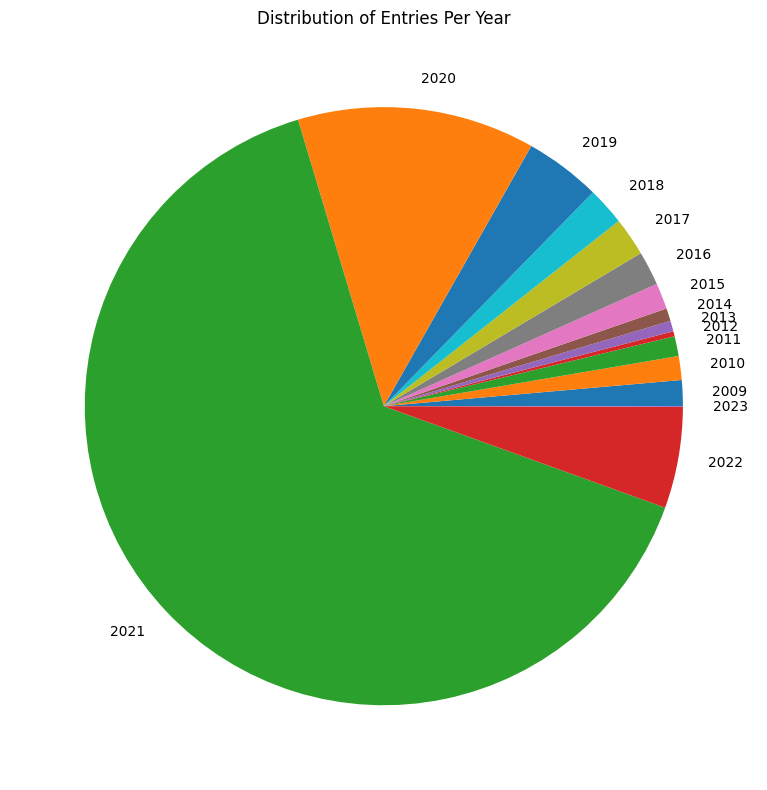

In [17]:
entries_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(8,8))
patches, texts = plt.pie(
    entries_per_year, 
    labels=entries_per_year.index.astype(str), 
    startangle=0
)
for t in texts:
    t.set_rotation(0)

plt.title("Distribution of Entries Per Year")
plt.tight_layout()
plt.show()

In [18]:
entries_per_year

year
2009     1195
2010     1102
2011      915
2012      233
2013      494
2014      593
2015     1202
2016     1578
2017     1780
2018     1755
2019     3523
2020    10986
2021    55492
2022     4679
2023       38
Name: count, dtype: int64

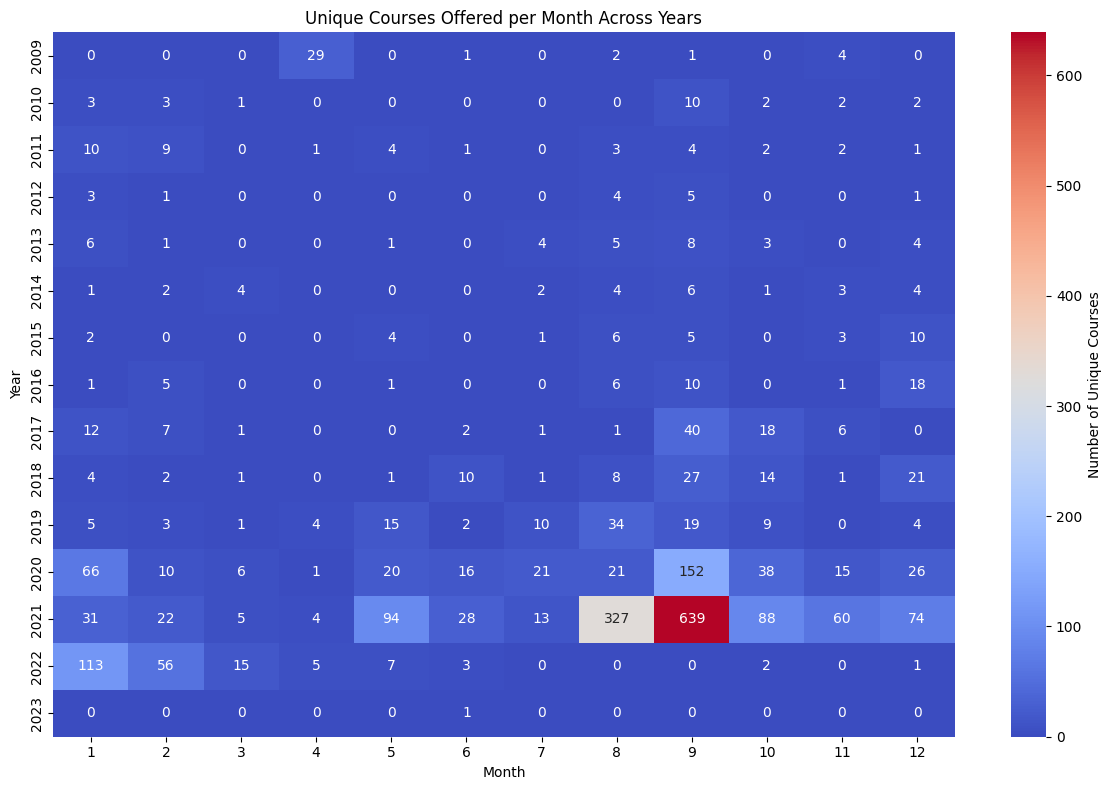

In [19]:
courses_per_month_year = (
    df.drop_duplicates(subset=['year', 'month', 'courseid'])
    .groupby(['year', 'month'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    courses_per_month_year,
    cmap='coolwarm',
    cbar_kws={'label': 'Number of Unique Courses'},
    annot=True,
    fmt='d',
    annot_kws={"size": 10}
)
plt.title('Unique Courses Offered per Month Across Years')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

## **Student tenure**

We will calculate how long each student has been active in the courses by finding the earliest and latest enrollment dates per student. 
From this, we can compute the tenure to see/plot the distribution of student's tenure.

In [20]:
student_tenure = (
    df.groupby('userid')['timecreated']
    .agg(['min', 'max'])
    .reset_index()
)

student_tenure

,userid,min,max
0,68739,2012-08-31 18:52:30,2021-12-06 20:38:26
1,68833,2021-05-20 17:08:08,2021-05-20 17:08:08
2,68918,2021-08-31 19:44:01,2021-08-31 19:44:01
3,68973,2021-08-20 19:03:06,2022-01-18 20:32:32
4,68991,2009-08-18 08:50:17,2021-08-31 20:23:36
...,...,...,...
15015,492539,2021-05-13 10:35:45,2021-05-13 10:35:45
15016,492541,2021-05-13 10:35:45,2021-05-13 10:35:45
15017,492558,2021-05-13 10:35:45,2021-05-13 10:35:45
15018,492586,2021-05-13 10:35:45,2021-05-13 10:35:45


In [21]:
student_tenure['tenure_days'] = (student_tenure['max'] - student_tenure['min']).dt.days
student_tenure['tenure_years'] = student_tenure['tenure_days'] / 365.25
student_tenure.sort_values(by='tenure_days', ascending=False)

,userid,min,max,tenure_days,tenure_years
10903,176575,2009-04-08 17:18:47,2023-06-28 13:45:39,5193,14.217659
74,73134,2009-04-08 17:18:47,2022-10-29 11:50:34,4951,13.555099
10987,176665,2009-04-14 06:46:00,2022-10-29 11:50:34,4946,13.541410
11827,177532,2009-04-14 06:46:00,2022-10-29 11:50:34,4946,13.541410
5222,163839,2009-04-14 06:46:00,2022-10-29 11:50:34,4946,13.541410
...,...,...,...,...,...
7703,169310,2021-08-31 20:23:36,2021-08-31 20:23:36,0,0.000000
7702,169309,2021-08-31 20:23:36,2021-08-31 20:23:36,0,0.000000
7701,169308,2021-08-31 20:23:36,2021-08-31 20:23:36,0,0.000000
7700,169307,2021-08-31 20:23:36,2021-08-31 20:23:36,0,0.000000


In [22]:
student_tenure['tenure_years'].describe()

count    15020.000000
mean         4.006432
std          4.389425
min          0.000000
25%          0.013689
50%          2.090349
75%          6.828200
max         14.217659
Name: tenure_years, dtype: float64

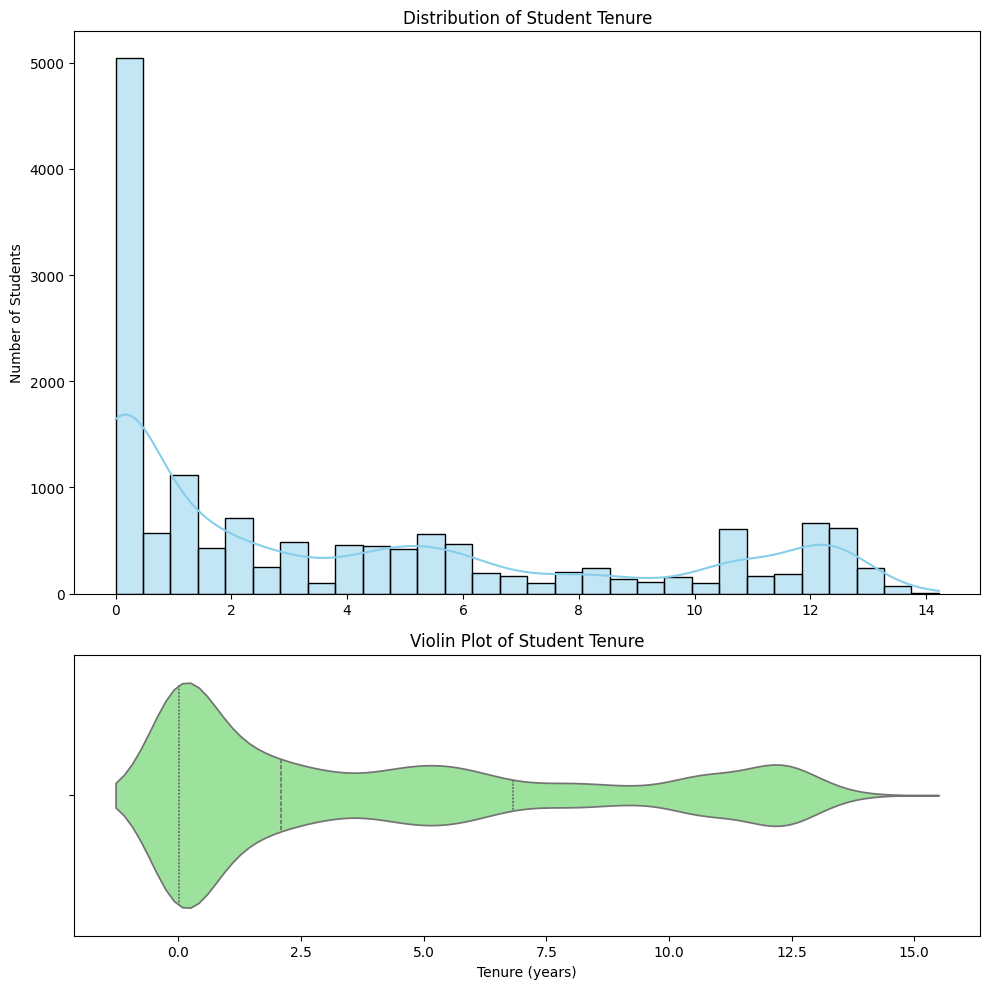

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(10,10), gridspec_kw={'height_ratios':[2,1]})

sns.histplot(student_tenure['tenure_years'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Student Tenure')
axes[0].set_ylabel('Number of Students')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_xlabel('')

sns.violinplot(x=student_tenure['tenure_years'], inner='quartile', ax=axes[1], color='lightgreen')
axes[1].set_title('Violin Plot of Student Tenure')
axes[1].set_xlabel('Tenure (years)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()